In [1]:
import sys
sys.path.insert(0, '../../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

np.random.seed(42)

In [2]:

# ── helpers ──────────────────────────────────────────────────────────────────

def fake_trf(n=60, attended=True):
    t = np.linspace(0, 1, n)
    if attended:
        return 0.6*np.exp(-((t-0.35)/0.08)**2) - 0.3*np.exp(-((t-0.55)/0.10)**2)
    else:
        return 0.25*np.exp(-((t-0.38)/0.10)**2) - 0.12*np.exp(-((t-0.58)/0.12)**2)

def fake_eeg(n=80):
    t = np.linspace(0, 1, n)
    return 0.4*np.sin(2*np.pi*4*t) + 0.2*np.sin(2*np.pi*8*t) + 0.3*np.random.randn(n)

def fake_envelope(n=120):
    t = np.linspace(0, 1, n)
    recon = 0.5 + 0.4*np.sin(2*np.pi*1.2*t) + 0.2*np.sin(2*np.pi*3.5*t) + 0.3*np.cos(2*np.pi*5.5*t)
    recon = np.clip(recon, 0, None)
    base = recon + 0.18*np.random.randn(n)
    base = np.clip(base, 0, None)
    return base, recon

def fake_corr(high=True):
    return np.random.uniform(0.15, 0.25) if high else np.random.uniform(0.05, 0.15)

def plot_signal(ax, y, color, lw=1.2, fill=False, alpha=1.0, label=None):
    x = np.linspace(0, 1, len(y))
    ax.plot(x, y, color=color, lw=lw, alpha=alpha, label=label)
    if fill:
        ax.fill_between(x, 0, y, color=color, alpha=0.18)
    ax.set_xlim(0, 1); ax.axis('off')

def plot_trf(ax, attended=True):
    y = fake_trf(attended=attended)
    x = np.linspace(0, 1, len(y))
    c = 'tab:blue' if attended else 'tab:orange'
    ax.plot(x, y, color=c, lw=1.5)
    ax.axhline(0, color='grey', lw=0.6, ls='--')
    ax.set_xlim(0,1); ax.axis('off')
    ax.set_ylim(-1,1)

def plot_eeg(ax, y):
    x = np.linspace(0, 1, len(y))
    ax.plot(x, y, color='#555', lw=1.0)
    ax.set_xlim(0,1); ax.axis('off')

def plot_overlay(ax, base, recon, c_base, c_recon):
    x = np.linspace(0, 1, len(base))
    #ax.fill_between(x, 0, base, color=c_base, alpha=0.25)
    ax.plot(x, base, color=c_base, lw=1.5, label='true')
    ax.plot(x, recon, color=c_recon, lw=1.2, ls='--', label='reconstructed')
    ax.set_xlim(0,1); ax.axis('off')

def corr_bar(ax, r, color):
    ax.barh(0, r, color=color, alpha=0.75, height=0.5)
    ax.set_xlim(0, 0.4); ax.set_ylim(-0.5, 0.5)
    ax.text(r + 0.03, 0, f'r = {r:.2f}', va='center', fontsize=7.5, color='k')
    ax.axvline(0, color='grey', lw=0.5)
    ax.axis('off')

def label_box(ax, text, fontsize=8, color='#333'):
    ax.text(0.5, 0.5, text, ha='center', va='center',
            fontsize=fontsize, color=color,
            transform=ax.transAxes, style='italic')
    ax.axis('off')

def add_arrow(fig, ax1, ax2, label='×', color='#444'):
    """Draw an arrow between two axes in figure coordinates."""
    x1 = ax1.get_position().x1
    y1 = ax1.get_position().y0 + ax1.get_position().height / 2
    x2 = ax2.get_position().x0
    y2 = ax2.get_position().y0 + ax2.get_position().height / 2
    mid_x = (x1 + x2) / 2
    fig.text(mid_x, (y1+y2)/2, label, ha='center', va='center',
             fontsize=11, color=color, fontweight='bold')
    ax = fig.add_axes([x1, min(y1,y2), x2-x1, abs(y2-y1)+0.001])
    ax.axis('off')


saved


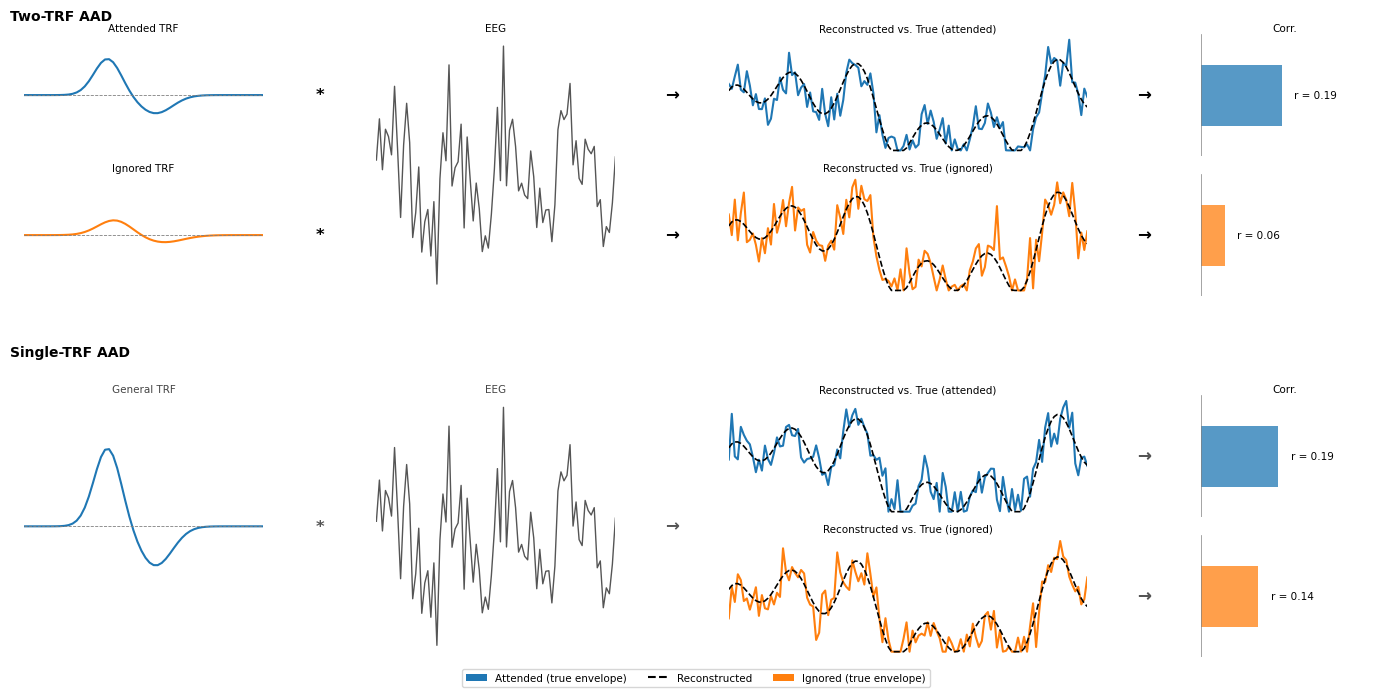

In [3]:
# ── layout ───────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 7))
fig.patch.set_facecolor('white')

# Outer rows
outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.38,
                          top=0.93, bottom=0.04, left=0.02, right=0.98)

# Row titles
fig.text(0.01, 0.95, 'Two-TRF AAD', fontsize=10, fontweight='bold', color='black')
fig.text(0.01, 0.47, 'Single-TRF AAD', fontsize=10, fontweight='bold', color='black')

# ─────────────────────────────────────────────────────────────────────────────
# ROW 1 : two TRF rows stacked
# cols: TRF | × | EEG | → | overlay | → | corr
#  sub-rows: attended (top) / ignored (bottom)
# ─────────────────────────────────────────────────────────────────────────────

r1 = gridspec.GridSpecFromSubplotSpec(2, 7, subplot_spec=outer[0],
      hspace=0.15,
      width_ratios=[2, 0.4, 2, 0.4, 3, 0.4, 1.4])

att_env, att_rec = fake_envelope()
ign_env, ign_rec = fake_envelope()
r_att = fake_corr(high=True)
r_ign = fake_corr(high=False)
eeg = fake_eeg()

# Attended row (sub-row 0)
ax_trf_att  = fig.add_subplot(r1[0, 0])
ax_eeg_att  = fig.add_subplot(r1[:, 2])
ax_ov_att   = fig.add_subplot(r1[0, 4])
ax_cor_att  = fig.add_subplot(r1[0, 6])

# Ignored row (sub-row 1)
ax_trf_ign  = fig.add_subplot(r1[1, 0])
ax_ov_ign   = fig.add_subplot(r1[1, 4])
ax_cor_ign  = fig.add_subplot(r1[1, 6])

# operator / arrow labels (col 1,3,5,7 for each sub-row)
for row_i, sub_row in enumerate([0, 1]):
    for col_i, sym in [(1,'*'), (3,'→'), (5,'→')]:
        ax = fig.add_subplot(r1[sub_row, col_i])
        ax.text(0.5, 0.5, sym, ha='center', va='center',
                fontsize=12, fontweight='bold', color='black',
                transform=ax.transAxes)
        ax.axis('off')

# fill content
plot_trf(ax_trf_att, attended=True)
ax_trf_att.set_title('Attended TRF', fontsize=7.5, pad=2, color='black')

plot_trf(ax_trf_ign, attended=False)
ax_trf_ign.set_title('Ignored TRF', fontsize=7.5, pad=2, color='black')

plot_eeg(ax_eeg_att, eeg)
ax_eeg_att.set_title('EEG', fontsize=7.5, pad=2, color='black')

plot_overlay(ax_ov_att, att_env, att_rec, 'tab:blue', 'black')
ax_ov_att.set_title('Reconstructed vs. True (attended)', fontsize=7.5, pad=2)
plot_overlay(ax_ov_ign, ign_env, ign_rec, 'tab:orange', 'black')
ax_ov_ign.set_title('Reconstructed vs. True (ignored)', fontsize=7.5, pad=2)

corr_bar(ax_cor_att, r_att, 'tab:blue')
ax_cor_att.set_title('Corr.', fontsize=7.5, pad=2)
corr_bar(ax_cor_ign, r_ign, 'tab:orange')

# brace / bracket on left side of row 1 to show EEG is shared
# simple line
pos_eeg_att = ax_eeg_att.get_position()

# ─────────────────────────────────────────────────────────────────────────────
# ROW 2 : single TRF
# cols: TRF | × | EEG | → | overlay_att / overlay_ign stacked | → | corr_att / corr_ign stacked
# ─────────────────────────────────────────────────────────────────────────────

r2 = gridspec.GridSpecFromSubplotSpec(2, 7, subplot_spec=outer[1],
      hspace=0.15,
      width_ratios=[2, 0.4, 2, 0.4, 3, 0.4, 1.4])

ax_trf_gen   = fig.add_subplot(r2[:, 0])   # spans both sub-rows
ax_eeg_gen   = fig.add_subplot(r2[:, 2])   # spans both sub-rows
ax_ov2_att   = fig.add_subplot(r2[0, 4])
ax_ov2_ign   = fig.add_subplot(r2[1, 4])
ax_cor2_att  = fig.add_subplot(r2[0, 6])
ax_cor2_ign  = fig.add_subplot(r2[1, 6])

for col_i, sym in [(1,'*'), (3,'→')]:
    ax = fig.add_subplot(r2[:, col_i])
    ax.text(0.5, 0.5, sym, ha='center', va='center',
            fontsize=12, fontweight='bold', color='#555',
            transform=ax.transAxes)
    ax.axis('off')

for sub_row, col_i, sym in [(0,5,'→'),(1,5,'→'),(0,5,'→'),(1,5,'→')]:
    ax = fig.add_subplot(r2[sub_row, col_i])
    ax.text(0.5, 0.5, sym, ha='center', va='center',
            fontsize=12, fontweight='bold', color='#555',
            transform=ax.transAxes)
    ax.axis('off')

plot_trf(ax_trf_gen, attended=True)  # neutral colour – reuse attended palette
ax_trf_gen.set_title('General TRF', fontsize=7.5, pad=2, color='#444')

plot_eeg(ax_eeg_gen, eeg)
ax_eeg_gen.set_title('EEG', fontsize=7.5, pad=2, color='#444')

att_env2, att_rec2 = fake_envelope()
ign_env2, ign_rec2 = fake_envelope()
r_att2 = fake_corr(high=True)
r_ign2 = fake_corr(high=False)

plot_overlay(ax_ov2_att, att_env2, att_rec2, 'tab:blue', "black")
ax_ov2_att.set_title('Reconstructed vs. True (attended)', fontsize=7.5, pad=2)
plot_overlay(ax_ov2_ign, ign_env2, ign_rec2, 'tab:orange', "black")
ax_ov2_ign.set_title('Reconstructed vs. True (ignored)', fontsize=7.5, pad=2)

corr_bar(ax_cor2_att, r_att2, 'tab:blue')
ax_cor2_att.set_title('Corr.', fontsize=7.5, pad=2)
corr_bar(ax_cor2_ign, r_ign2, 'tab:orange')

# ── legend ───────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor='tab:blue', alpha=1, label='Attended (true envelope)'),
    plt.Line2D([0],[0], color='black', lw=1.5, ls='--', label='Reconstructed'),
    mpatches.Patch(facecolor='tab:orange', alpha=1, label='Ignored (true envelope)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=7.5, frameon=True, bbox_to_anchor=(0.5, -0.01))

plt.savefig(BEYOND_FIGURES_DIR / 'aad_approaches.png', dpi=180,
            bbox_inches='tight', facecolor='white')
print("saved")
